In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


orders = pd.read_csv("olist_orders_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

In [19]:

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])


orders['delivery_time'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders['delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days


orders = orders.dropna(subset=['order_delivered_customer_date'])

In [20]:
total_revenue = payments['payment_value'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 16008872.120000001


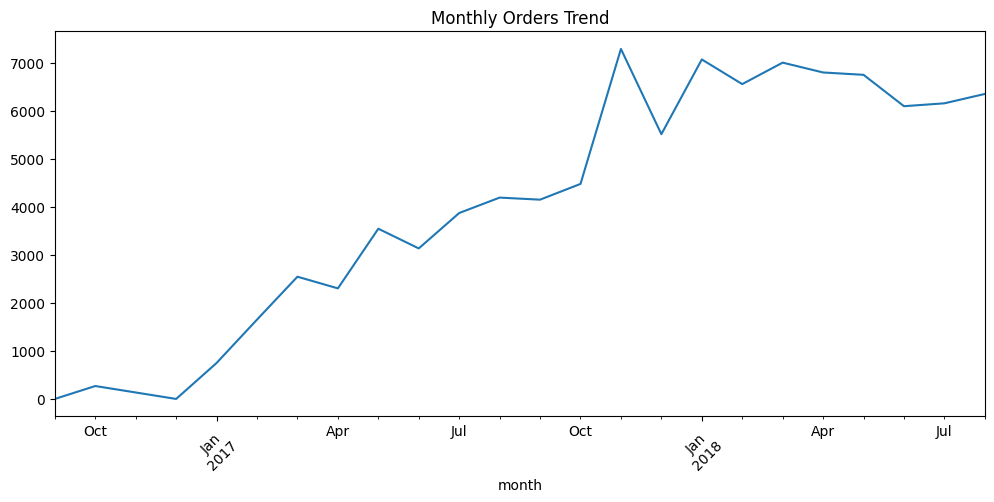

In [21]:
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders.groupby('month').size()

monthly_orders.plot(figsize=(12,5))
plt.title("Monthly Orders Trend")
plt.xticks(rotation=45)
plt.show()

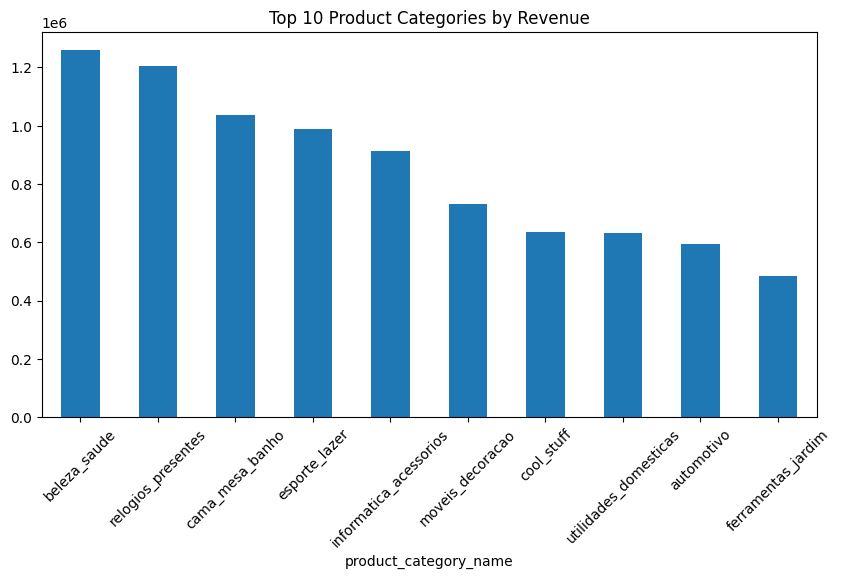

In [22]:
merged = items.merge(products, on='product_id')
category_sales = merged.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10)

category_sales.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Product Categories by Revenue")
plt.xticks(rotation=45)
plt.show()

In [23]:
orders_customers = orders.merge(customers, on='customer_id')

customer_orders = orders_customers.groupby(
    'customer_unique_id'
).size()

one_time = (customer_orders == 1).sum()
repeat = (customer_orders > 1).sum()

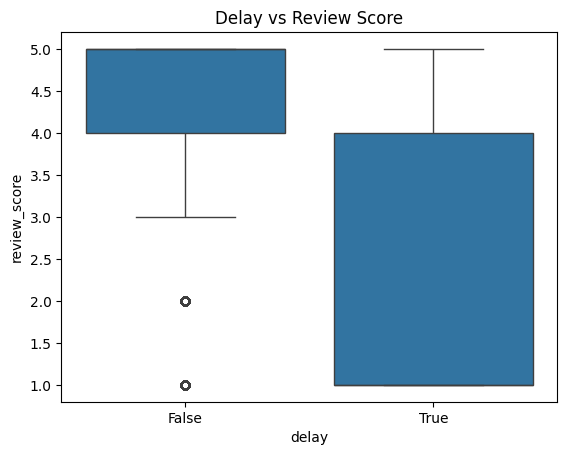

In [24]:
delay_reviews = orders.merge(reviews, on='order_id')

sns.boxplot(x=delay_reviews['delay'] > 0, y=delay_reviews['review_score'])
plt.title("Delay vs Review Score")
plt.show()

## Executive Insights

1. Monthly orders show continuous growth.
2. Beauty and health categories generate highest revenue.
3. Delivery delays negatively affect customer reviews.
4. Majority of customers purchase once, indicating retention opportunity.